## Connections between cathegories

In [9]:
library(tidyverse)
connections_between_cathegories <- read_csv(
    "networks/results/connections_between_cathegories.csv"
)

New names:
• `` -> `...1`
Rows: 22 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ...1
dbl (23): Accelerator Physics, Applied Physics, Atmospheric and Oceanic Phys...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [34]:
all_physics_topics = c("Accelerator Physics", "Applied Physics", "Atmospheric and Oceanic Physics", "Atomic and Molecular Clusters", 
                      "Atomic Physics", "Biological Physics", "Chemical Physics", "Classical Physics", "Computational Physics", 
                      "Data Analysis, Statistics and Probability", "Fluid Dynamics", "General Physics", "Geophysics", 
                      "History and Philosophy of Physics", "Instrumentation and Detectors", "Medical Physics", "Optics",
                        "Physics and Society", "Physics Education", "Plasma Physics", "Popular Physics", "Space Physics")

for(i in (1:22)){
  max_connections_for_topic <- connections_between_cathegories %>%
    select(c("...1", all_physics_topics[i])) %>%
    mutate("Cathegory" = all_physics_topics[i], "Number_of_papers" = connections_between_cathegories$Number_of_papers[i])

  colnames(max_connections_for_topic) <- c("Max_connected_cathegory", "Connections", "Cathegory", "Number_of_papers")
  max_connections_for_topic <- max_connections_for_topic %>%
    filter(Connections == max(Connections)) %>%
    select(c("Cathegory", "Number_of_papers", "Max_connected_cathegory", "Connections"))
  if(i == 1){
    max_connections <- max_connections_for_topic
  }
  else{
    max_connections <- bind_rows(max_connections, max_connections_for_topic)
  }
}

In [35]:
max_connections

Cathegory,Number_of_papers,Max_connected_cathegory,Connections
<chr>,<dbl>,<chr>,<dbl>
Accelerator Physics,486,Accelerator Physics,2323
Applied Physics,1929,Optics,7086
Atmospheric and Oceanic Physics,772,Atmospheric and Oceanic Physics,3839
Atomic and Molecular Clusters,91,Atomic Physics,361
Atomic Physics,1355,Atomic Physics,14396
Biological Physics,1062,Biological Physics,2846
Chemical Physics,2216,Chemical Physics,10146
Classical Physics,394,Fluid Dynamics,1305
Computational Physics,2134,Computational Physics,6234


We can see that for almost all cathegories, the maximum number of connections is to papers of the same cathegory. The only cases in which this is not true, the max connected cathegory is still a similar cathegory (for example classical physics and fluid dynamics, and atomic and molecular clusters with atomic physics).

## Analyze connected components

In [1]:
library(tidyverse)
components <- read_csv(
    "networks/results/connected_components.csv"
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 10 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (4): ...1, Threshold, Connected_components, Largest_component

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
components

...1,Threshold,Connected_components,Largest_component
<dbl>,<dbl>,<dbl>,<dbl>
0,0.1500000,89,25788
1,0.1888889,665,25179
2,0.2277778,2856,22794
3,0.2666667,7507,17347
4,0.3055556,13298,9960
5,0.3444444,18305,2971
6,0.3833333,21486,193
7,0.4222222,23366,49
8,0.4611111,24431,30


Degree distribution looks like a power law, but of course this needs to be verified. Certainly we don't have a random network.

OLD COMMENT FOR OLD NETWORK

For what we can see, the papers with the highest degree are those with a short abstract, or written in another language (typically Spanish). Since they don't have much words in common with the other papers, their distance tends to 0, so they have a lot of links. Then I need to check two roads:

1) Maybe we made an error: it is better to put a link between papers with distance higher than a certain value, meaning that they have a lot of words in common
2) If the method above does not work, try to remove the papers with the highest degrees, and study the remaining network (hoping that it clusters the topics).

Probably the best solution is to try both ways.

The significative difference between mean and median makes it easy to think that we are not in front of a symmetric distribution, so it is another proof against the random network hypothesis

## Plot degree versus clustering coefficient/eigenvector centrality/knn

In [25]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/abstract_embeddings/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [2]:
colnames(centrality_measures)

[1] "...1"                   "Degree"                 "Clustering_coefficient"
[4] "Eigenvector_centrality" "Mean_degree_NN"

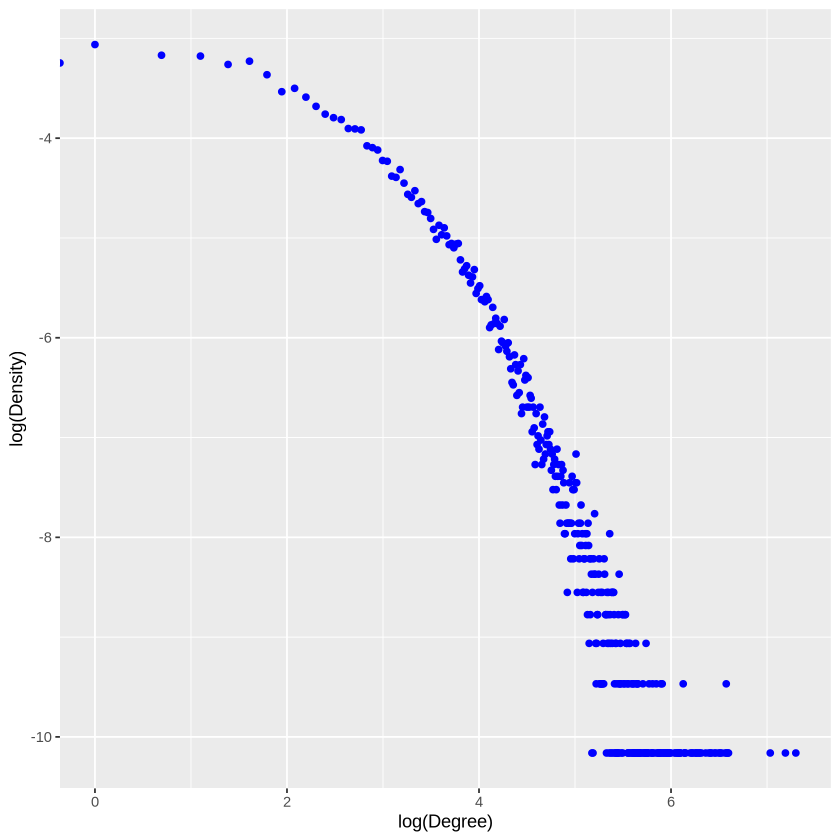

In [3]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = log(Degree), y = log(Density))) +
    geom_point(color = "blue")

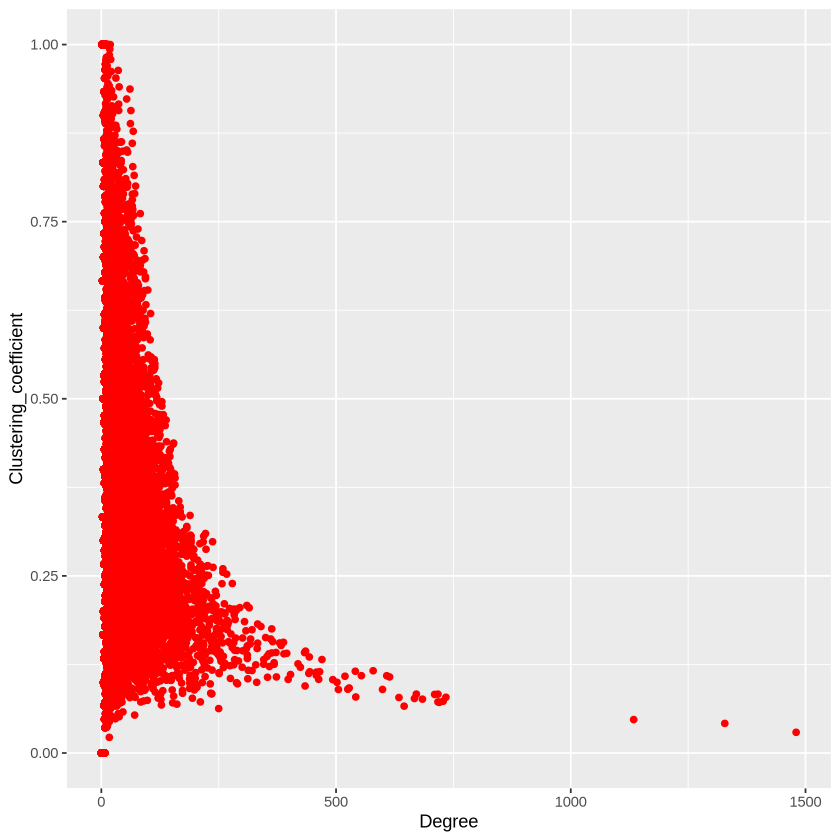

In [6]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

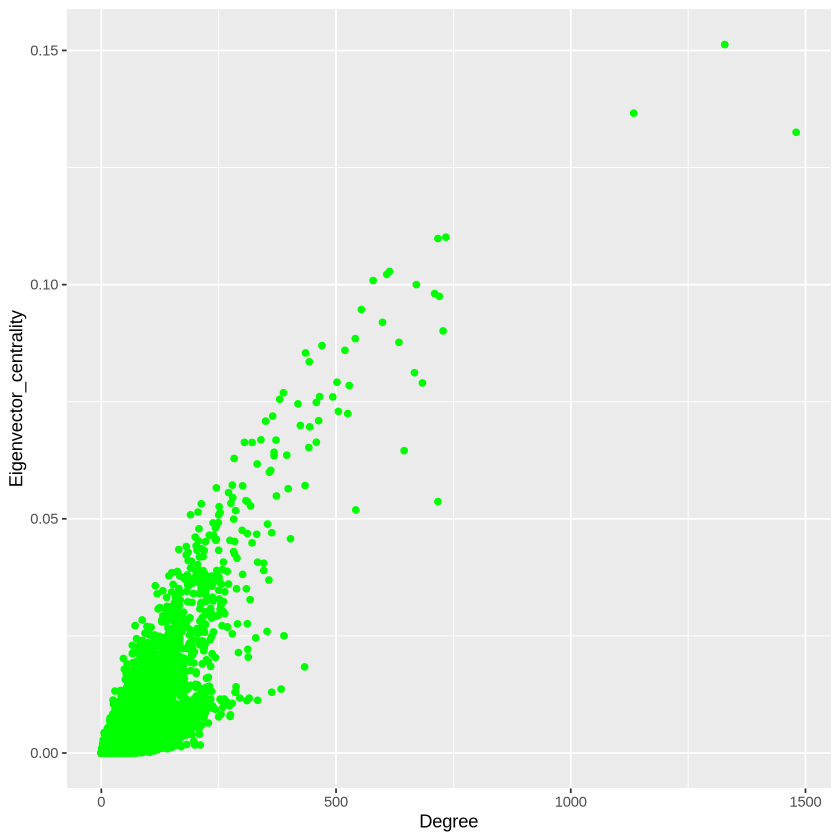

In [7]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

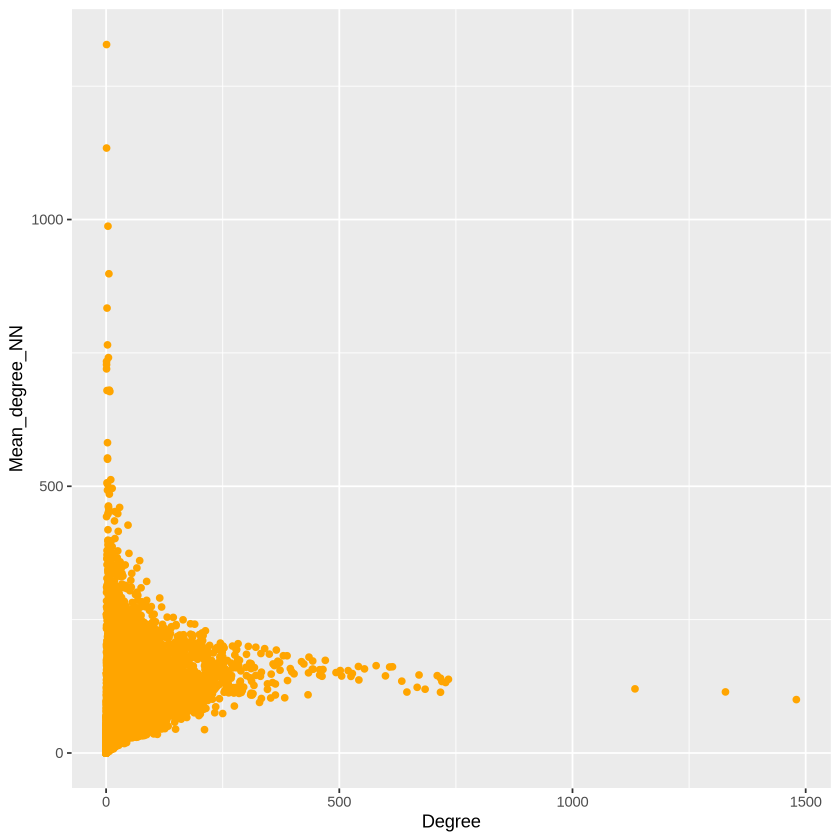

In [8]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

From this plot we can see that the three nodes with higher degrees are connected to lower degree nodes (otherwise the mean degree of their nearest neighbours would be much higher).

WRONG: the three nodes with higher degree are actually connected between them. It is just that the other nodes connected to them have a lower degree, and so the mean decreases a lot.

## Analyze network degrees

In [26]:
#create a unique dataset with the papers and their degree (and topic)
all_papers <- read_csv(
    "data/all_papers.csv"
)
all_data <- bind_cols(all_papers, centrality_measures)

New names:
• `` -> `...1`
Rows: 25877 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): authors, title, abstract, primary_cathegory, secondary_cathegory
dbl (2): ...1, paper

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `...1` -> `...8`


In [28]:
all_data %>%
    select(c("paper", "title", "primary_cathegory", "secondary_cathegory", "Degree")) %>%
    mutate("Index" = c(0:(nrow(all_data) - 1))) %>%
    arrange(desc(Degree)) %>%
    top_n(10, Degree)

paper,title,primary_cathegory,secondary_cathegory,Degree,Index
<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>
2512.205,Precision spectroscopy of the 2S-$n$P transitions in atomic hydrogen,Atomic Physics,Atomic Physics,1480,17128
2508.166,Classical Dirac particle II. Interaction with an electromagnetic plane wave,Classical Physics,Classical Physics,1328,10651
2507.147,Nuclear-spin-related properties of~the dual-frequency Doppler-free resonance,Atomic Physics,Atomic Physics,1134,9132
2512.119,Data-driven modeling of multivariate stochastic trajectories -- Application to water waves,Fluid Dynamics,"Data Analysis, Statistics and Probability",734,16526
2507.139,Novel techniques of imaging interferometry analysis to study gas and plasma density for laser-plasma experiments,Plasma Physics,"Data Analysis, Statistics and Probability",728,9091
2509.233,Two-photon ionization of the K-shell of a heavy beryllium-like atomic ion,Atomic Physics,Atomic Physics,720,12460
2503.206,An exact solution of the lubrication equations for the Oldroyd-B model in a hyperbolic channel,Fluid Dynamics,Fluid Dynamics,717,3787
2505.048,An Introduction to Variational Quantum Eigensolver Applied to Chemistry,Quantum Physics,Chemical Physics,717,20387
2512.097,Surface Ion-Sound Wave in Magnetic Arch With High Pressure Plasma,Plasma Physics,Plasma Physics,710,16369


These are the three papers with higher degree

In [4]:
## filter nodes with degree 0 and 1
core_data <- all_data %>%
    filter(Degree != 0 & Degree != 1)

In [5]:
nrow(core_data)

[1] 23659

The number of nodes with degree higher than 1 in the original network is close to the number of nodes remained after the removal of pendant nodes. So the network is composed by a strong component where each node has at least two links: paper are highly connected between them. We will see how we can separate them into communities.

At this point it is also useless to compute centrality measures for the network after pendant nodes removal: they will be very similar to those obtained with the original network.

## Comparison with random network

In [9]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/random_network/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


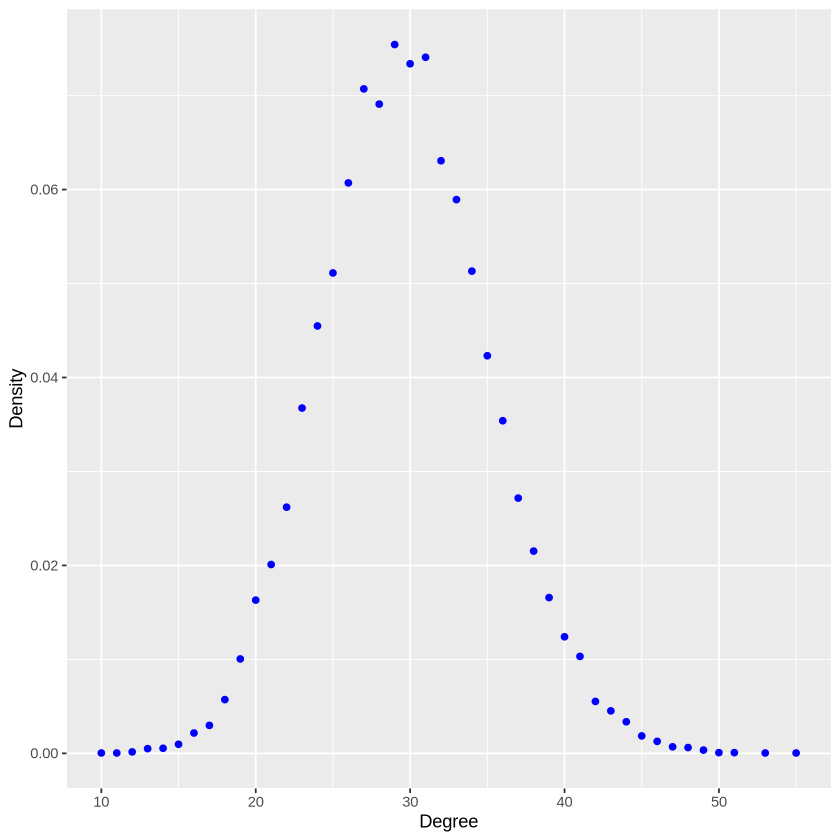

In [11]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = Degree, y = Density)) +
    geom_point(color = "blue")

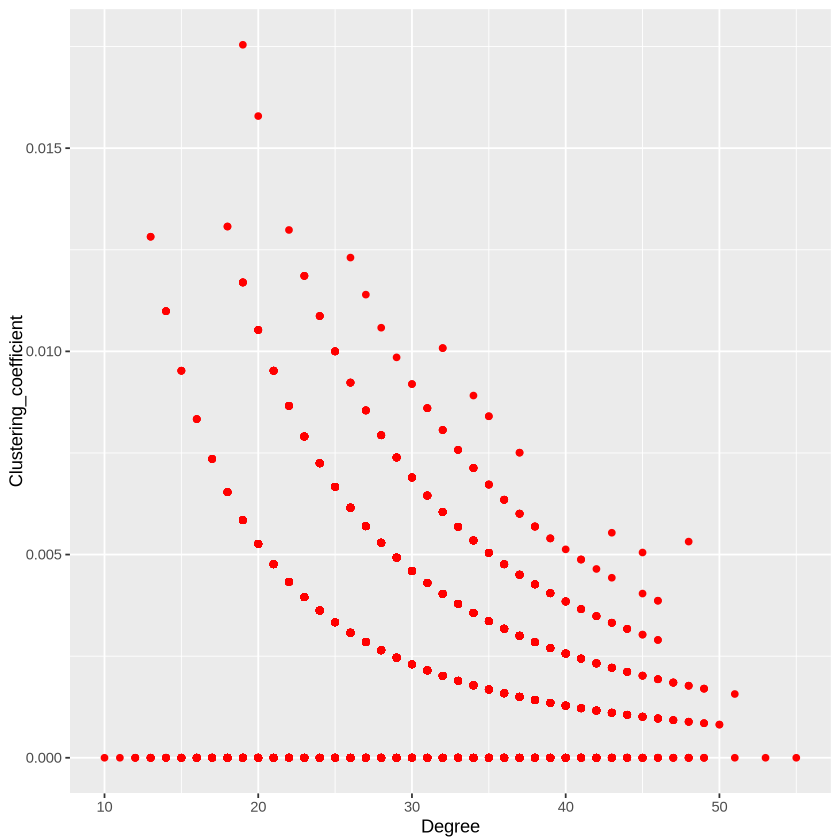

In [12]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

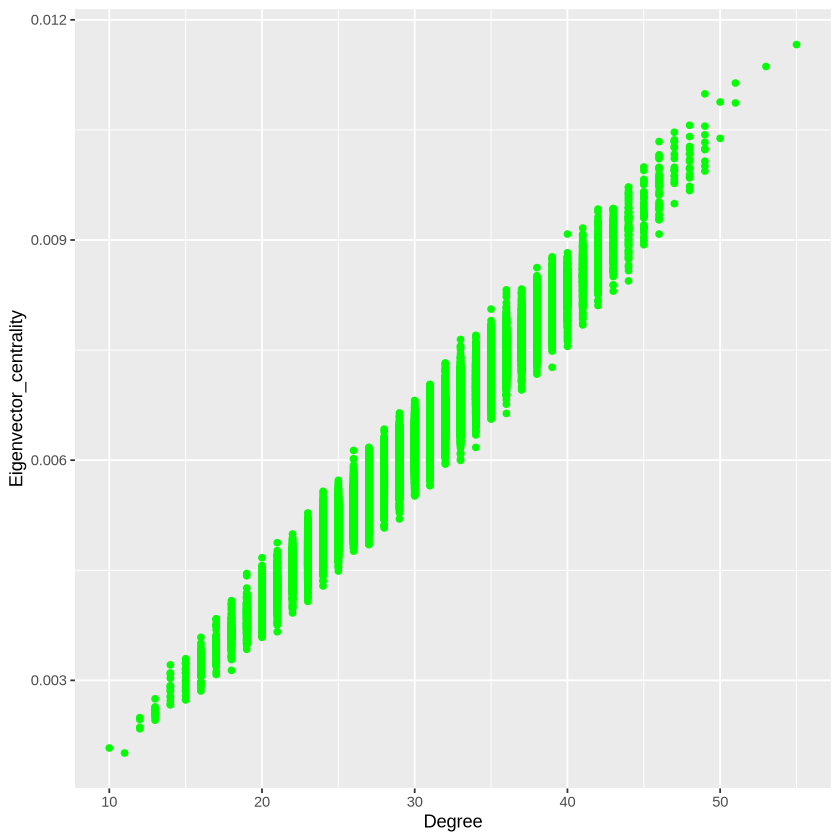

In [13]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

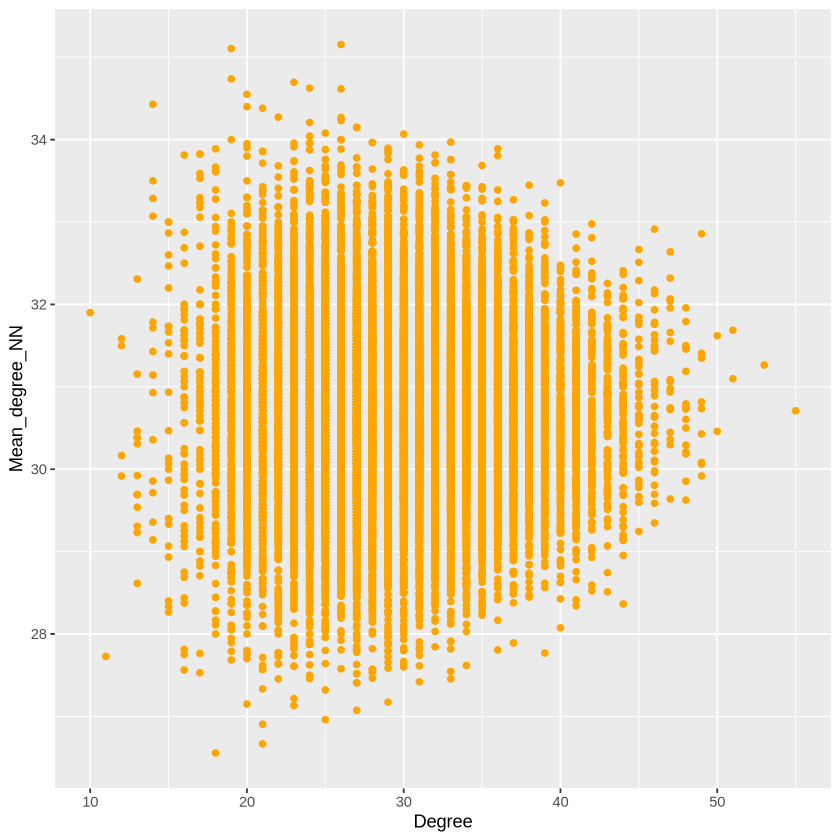

In [14]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

Completely random relation between k and knn, as expected

## Comparison with scale free

In [15]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/scale_free_network/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


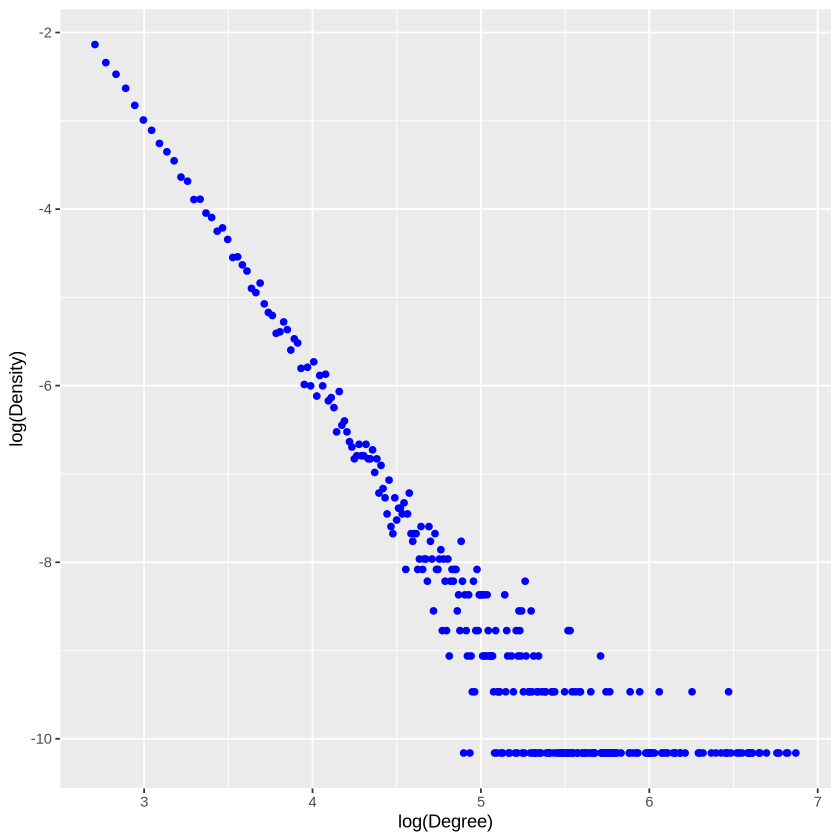

In [16]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = log(Degree), y = log(Density))) +
    geom_point(color = "blue")

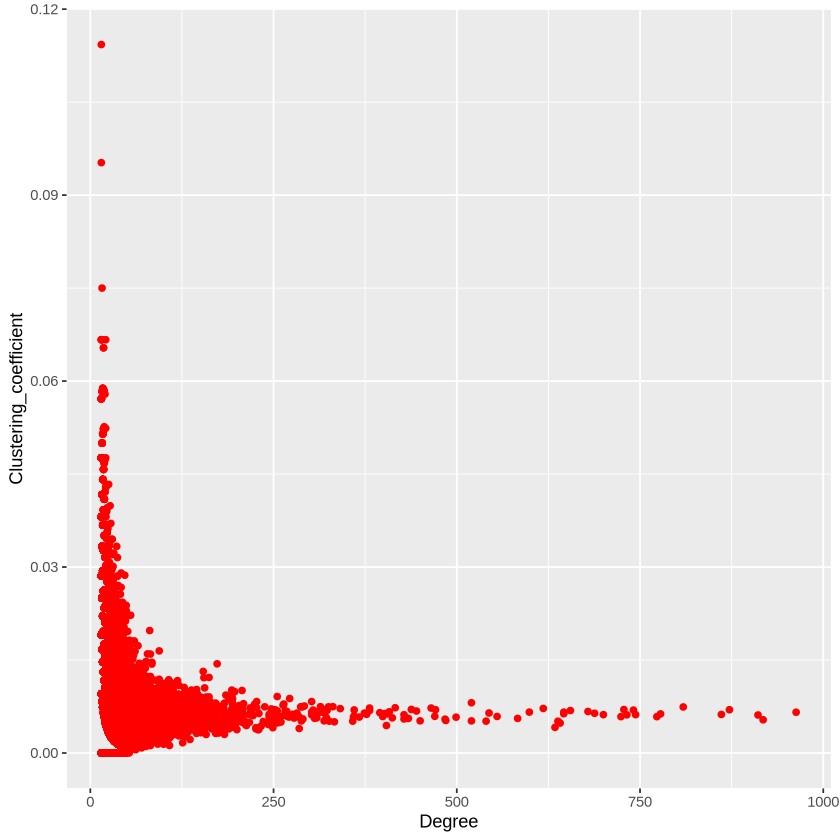

In [17]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

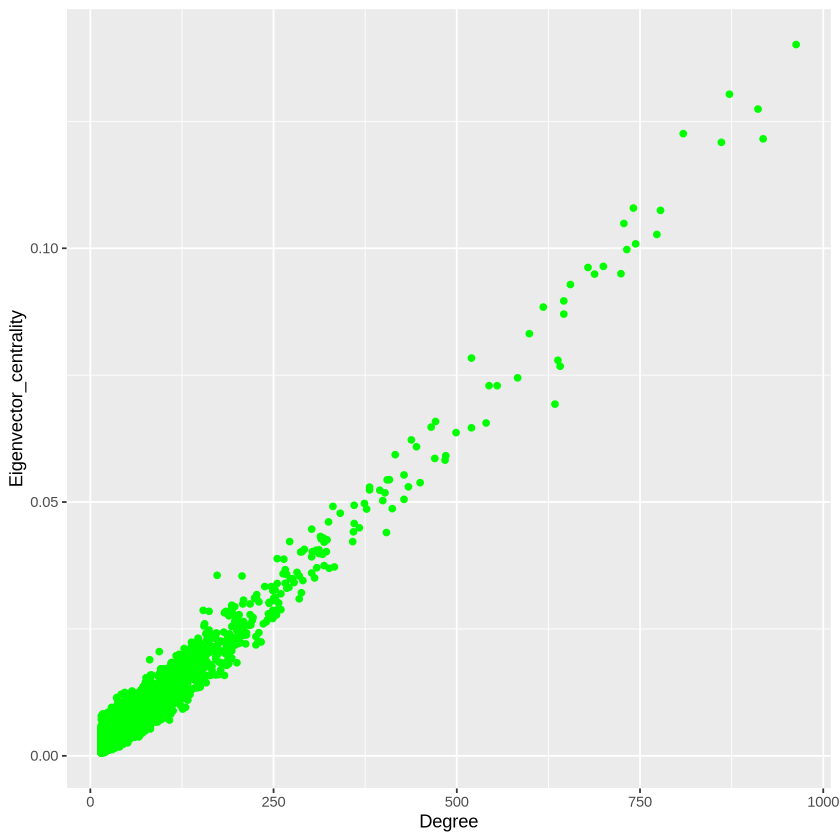

In [18]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

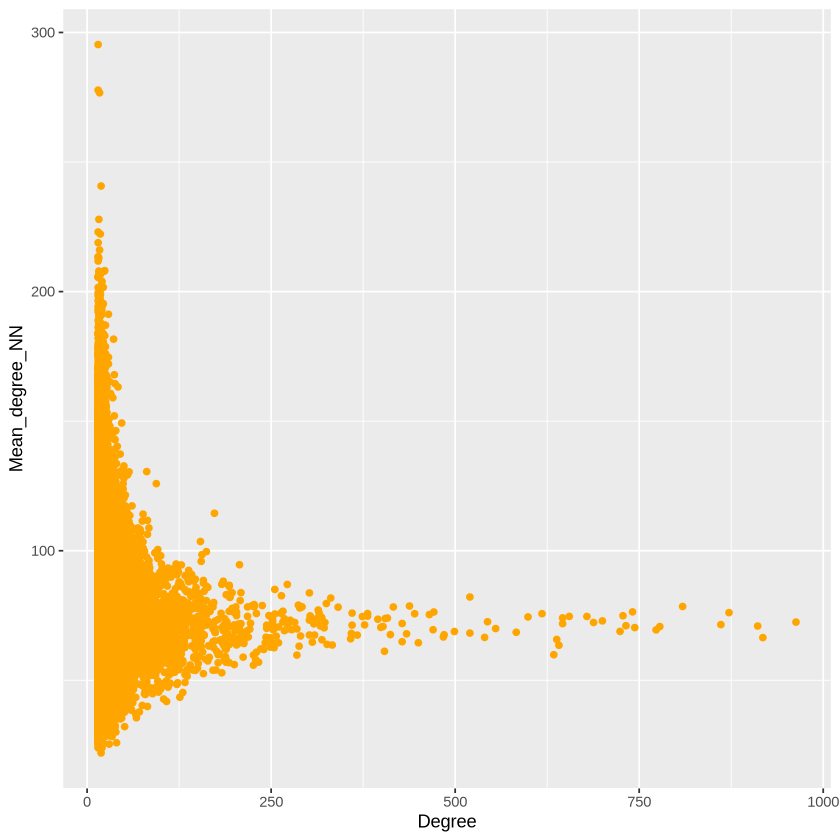

In [19]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

These plots are more similar to the real one we obtain. However, there is no visible reason to have a power law, in principle there shouldn't be preferential attachment. Maybe it could mean that some papers are more "general" and thus more similar to others. This is an aspect that should be investigated.

In the final report you can remove the random graph, clearly it is not a correct null model for our graph.

## Comparison with graph after node removal

In [29]:
library(tidyverse)
centrality_measures <- read_csv(
    "networks/results/abstract_node_removal/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25867 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


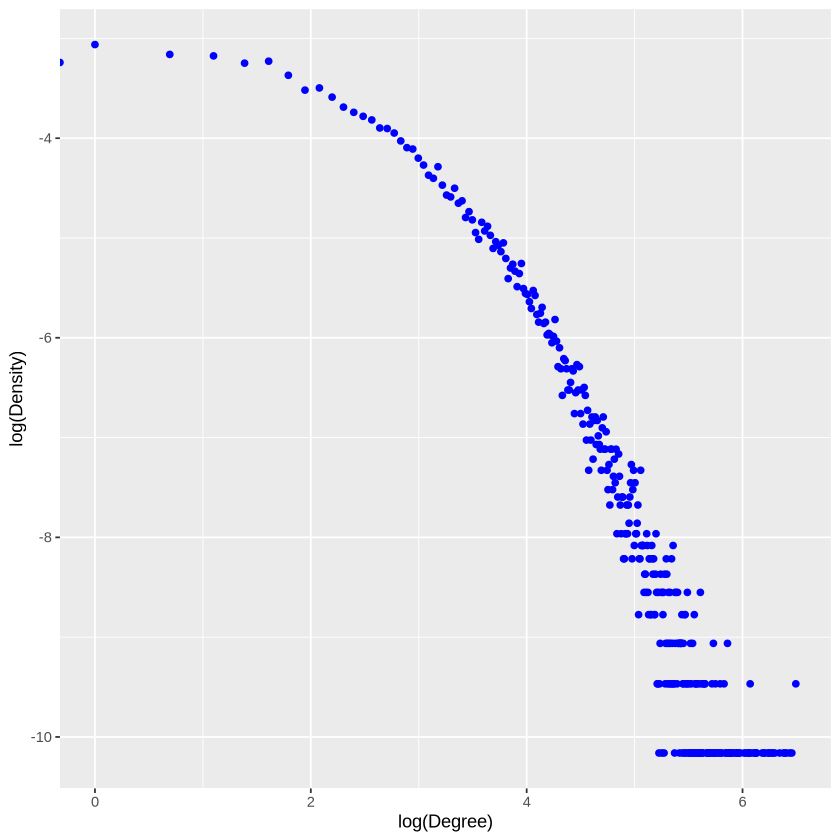

In [30]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = log(Degree), y = log(Density))) +
    geom_point(color = "blue")

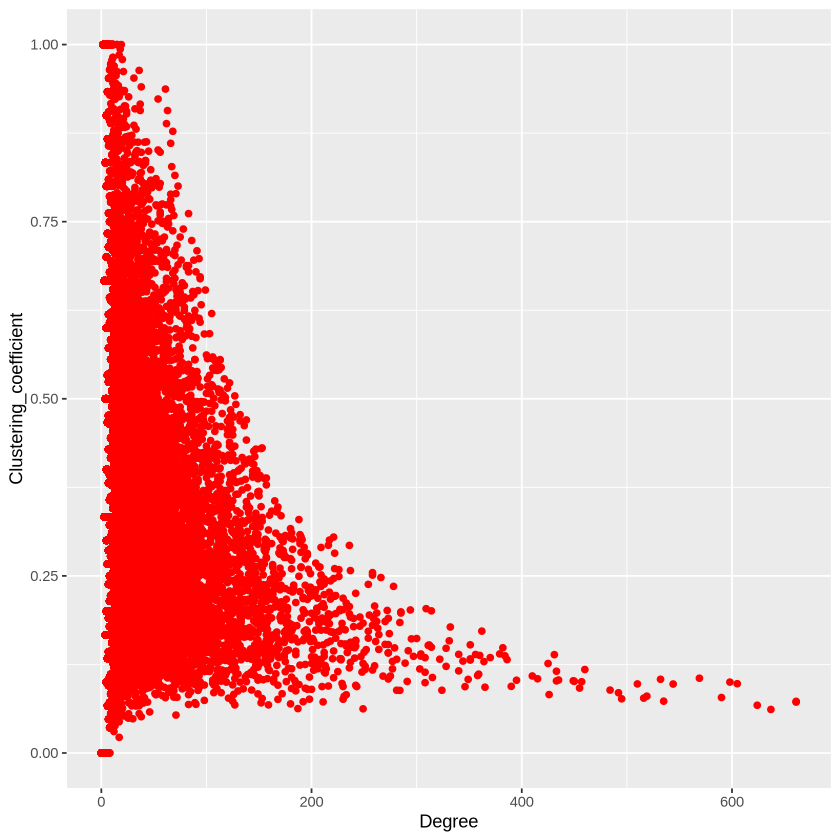

In [31]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

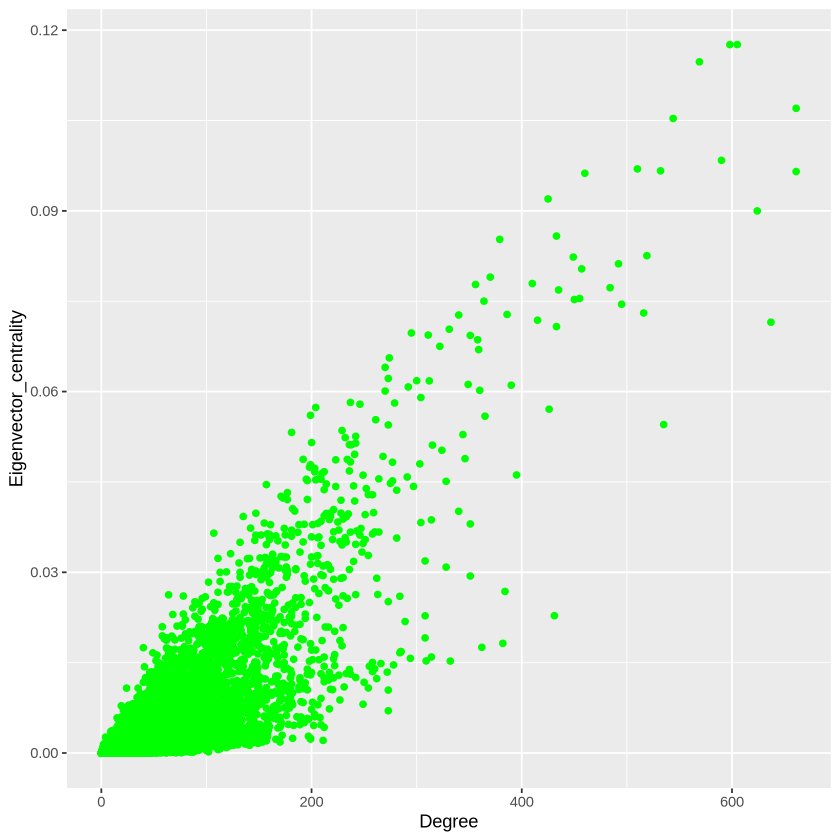

In [32]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

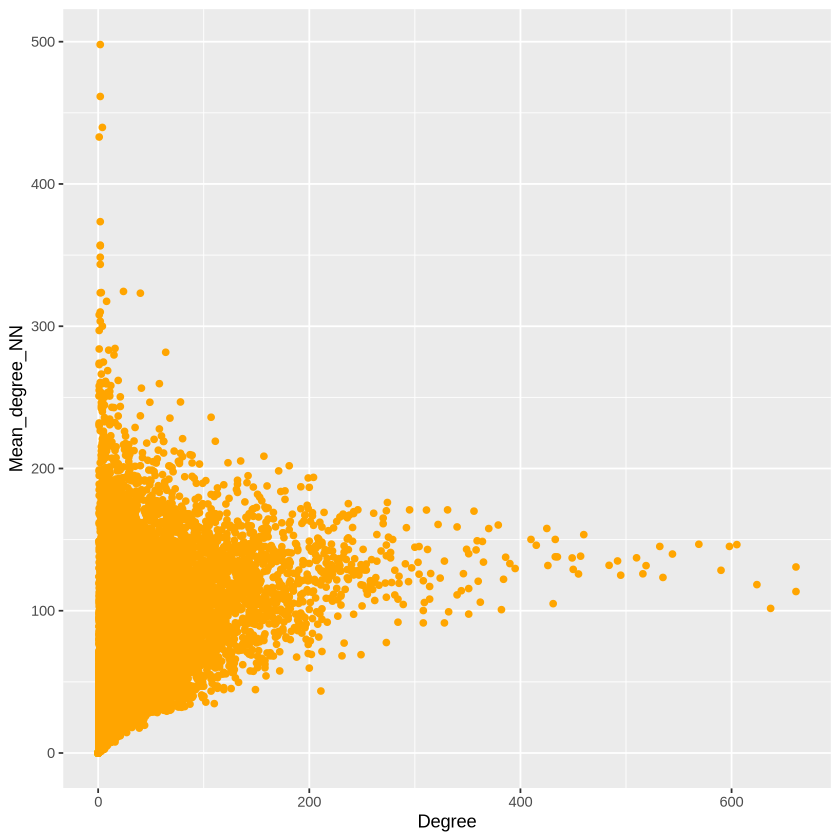

In [33]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

Clearly the removal of higher degree nodes does not change the centrality measures. The network is resistant to attacks to largest degree nodes. It is like the network has a sort of lattice structure (not regular of course, since we have some nodes with a lot of links), in which the removal of some nodes does not really alter the structure.

Even removing up to 10 nodes does not alter the structure.